# Martching Conditions: Astrophysical Shock Front

Simple Shock Front


Interior: Friedmann-Robertson-Walker (uniformly expanding or contracting space)

Exterior: Oppenheimer-Tolman (time-independent interior of a star)

### Coordinates and Function to Compute Scalars

In [1]:
import sympy as sp

# ============================================
# Coordinates
# ============================================

r, t, theta = sp.symbols('r t theta', real=True)

# ============================================
# Function
# ============================================

def compute_variables(A, B, R):

    a1 = sp.diff(A, r)/(B*A)

    sigma1 = sp.diff(B, t)/(A*B)

    sigma2 = sp.diff(R, t)/(A*R)

    J1 = sp.diff(R, r)/(B*R)

    J2 = sp.cot(theta)/R

    return a1, sigma1, sigma2, J1, J2


### Friedmann-Robertson-Walker Metric Functions

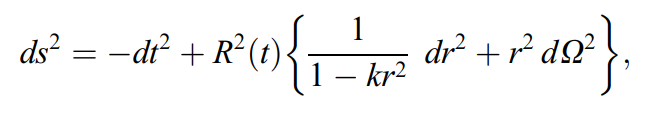

In [2]:
m = sp.Symbol('m', positive=True)

A1 = sp.sqrt(1-2*m/r)
B1 = 1/ sp.sqrt(1-2*m/r)
R1 = r

a1_Schwarz, sigma1_Schwarz, sigma2_Schwarz, J1_Schwarz, J2_Schwarz = compute_variables(A1, B1, R1)

print("\n=== Schwarzschild ===")
print("a1= ", a1_Schwarz)
print("sigma1= ", sigma1_Schwarz)
print("sigma2= ", sigma2_Schwarz)
print("J1= ", J1_Schwarz)
print("J2= ", J2_Schwarz)



=== Schwarzschild ===
a1=  m/(r**2*sqrt(-2*m/r + 1))
sigma1=  0
sigma2=  0
J1=  sqrt(-2*m/r + 1)/r
J2=  cot(theta)/r


In [3]:
A1_latex = sp.latex(A1)
print(A1_latex)


\sqrt{- \frac{2 m}{r} + 1}


In [4]:
B1_latex = sp.latex(B1)
print(B1_latex)

\frac{1}{\sqrt{- \frac{2 m}{r} + 1}}


### Oppenheimer-Tolman Metric Functions

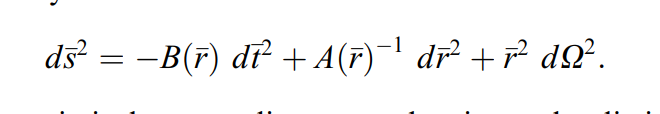

In [5]:
alpha = sp.symbols('alpha', positive=True)

A2 = sp.sqrt(1-r**2/alpha**2)
B2 = 1/sp.sqrt(1-r**2/alpha**2)
R2 = r

a1_Sit, sigma1_Sit, sigma2_Sit, J1_Sit, J2_Sit = compute_variables(A2, B2, R2)

print("\n=== de Sitter ===")
print("a1= ", a1_Sit)
print("sigma1= ", sigma1_Sit)
print("sigma2= ", sigma2_Sit)
print("J1= ", J1_Sit)
print("J2= ", J2_Sit)


=== de Sitter ===
a1=  -r/(alpha**2*sqrt(1 - r**2/alpha**2))
sigma1=  0
sigma2=  0
J1=  sqrt(1 - r**2/alpha**2)/r
J2=  cot(theta)/r


In [6]:
A2_latex = sp.latex(A2)
print(A2_latex)

\sqrt{1 - \frac{r^{2}}{\alpha^{2}}}


In [7]:
B2_latex = sp.latex(B2)
print(B2_latex)

\frac{1}{\sqrt{1 - \frac{r^{2}}{\alpha^{2}}}}


### Properties of $\Sigma$

In [8]:
rho, P = sp.symbols('rho P', real=True)

rho_sigma = rho
P_sigma = P
Pi_sigma = 0
F_sigma = 0

### Continuity of First Fundamental Form

$$\dot c= \sqrt{ \frac{\llbracket A^2 \rrbracket}{\llbracket B^2 \rrbracket } }$$


In [9]:
c0=sp.sqrt((A1**2-A2**2)/(B1**2-B2**2))
print(c0)

sqrt((-2*m/r + r**2/alpha**2)/(1/(-2*m/r + 1) - 1/(1 - r**2/alpha**2)))


In [10]:
latex = sp.latex(c0)
print(latex)

\sqrt{\frac{- \frac{2 m}{r} + \frac{r^{2}}{\alpha^{2}}}{\frac{1}{- \frac{2 m}{r} + 1} - \frac{1}{1 - \frac{r^{2}}{\alpha^{2}}}}}


### Israel Condition

$$\begin{split}
\dot{c} =
\frac{
2\llbracket A (\sigma_1 - a_1 )\rrbracket
\llbracket B (\sigma_1 - a_1 ) \rrbracket
\pm
\left( \frac{1}{2} \rho_\Sigma + 2 P_\Sigma -F_\Sigma \right)
\sqrt{
\begin{aligned}
&(B^\pm)^2
\llbracket A (\sigma_1 - a_1 ) \rrbracket^2 \\
&- (A^\pm)^2
\llbracket B (\sigma_1 - a_1 ) \rrbracket^2 \\
&- (A^\pm)^2 (B^\pm)^2
\left(
\frac{1}{2} \rho_\Sigma + 2 P_\Sigma -F_\Sigma
\right)^2
\end{aligned}
}
}{
2 \left(
\llbracket B (\sigma_1 - a_1 ) \rrbracket^2
+ (B^\pm)^2
\left(
\frac{1}{2} \rho_\Sigma + 2 P_\Sigma -F_\Sigma
\right)^2
\right)
}
\end{split}$$

In [11]:
# Jump operator: [[X]] = X_out - X_in
jump_A = A1*(sigma1_Schwarz - a1_Schwarz) - A2*(sigma1_Sit - a1_Sit)
jump_B = B1*(sigma1_Schwarz - a1_Schwarz) - B2*(sigma1_Sit - a1_Sit)

S = rho_sigma/2 + 2*P_sigma - F_sigma

# Choose either the exterior (+) or interior (-) side
Apm = A1
Bpm = B1

c_plus = (
    2*jump_A*jump_B
    + S*sp.sqrt(
        Bpm**2 * jump_A**2
        - Apm**2 * jump_B**2
        - Apm**2 * Bpm**2 * S**2
    )
) / (
    2 * (
        jump_B**2
        + Bpm**2 * S**2
    )
)

c_minus = (
    2*jump_A*jump_B
    - S*sp.sqrt(
        Bpm**2 * jump_A**2
        - Apm**2 * jump_B**2
        - Apm**2 * Bpm**2 * S**2
    )
) / (
    2 * (
        jump_B**2
        + Bpm**2 * S**2
    )
)

In [12]:
expr = c_plus #sp.simplify(c)
print(expr)

((2*P + rho/2)*sqrt(-(2*P + rho/2)**2 + (-m/r**2 - r/alpha**2)**2/(-2*m/r + 1) - (-2*m/r + 1)*(-m/(r**2*(-2*m/r + 1)) - r/(alpha**2*(1 - r**2/alpha**2)))**2) + (-2*m/r**2 - 2*r/alpha**2)*(-m/(r**2*(-2*m/r + 1)) - r/(alpha**2*(1 - r**2/alpha**2))))/(2*(2*P + rho/2)**2/(-2*m/r + 1) + 2*(-m/(r**2*(-2*m/r + 1)) - r/(alpha**2*(1 - r**2/alpha**2)))**2)


In [13]:
latex = sp.latex(expr)
print(latex)

\frac{\left(2 P + \frac{\rho}{2}\right) \sqrt{- \left(2 P + \frac{\rho}{2}\right)^{2} + \frac{\left(- \frac{m}{r^{2}} - \frac{r}{\alpha^{2}}\right)^{2}}{- \frac{2 m}{r} + 1} - \left(- \frac{2 m}{r} + 1\right) \left(- \frac{m}{r^{2} \left(- \frac{2 m}{r} + 1\right)} - \frac{r}{\alpha^{2} \left(1 - \frac{r^{2}}{\alpha^{2}}\right)}\right)^{2}} + \left(- \frac{2 m}{r^{2}} - \frac{2 r}{\alpha^{2}}\right) \left(- \frac{m}{r^{2} \left(- \frac{2 m}{r} + 1\right)} - \frac{r}{\alpha^{2} \left(1 - \frac{r^{2}}{\alpha^{2}}\right)}\right)}{\frac{2 \left(2 P + \frac{\rho}{2}\right)^{2}}{- \frac{2 m}{r} + 1} + 2 \left(- \frac{m}{r^{2} \left(- \frac{2 m}{r} + 1\right)} - \frac{r}{\alpha^{2} \left(1 - \frac{r^{2}}{\alpha^{2}}\right)}\right)^{2}}
